## Total least square regression
 - for ratings in different conditions (N-R, N-I, R-I)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
from glob import glob
plt.style.use("seaborn-v0_8-whitegrid")

def load_human_data():
    return pd.read_csv("sentences.csv")

def load_model_data(path, open_source=True):
    files = glob(path)
    data = []
    for file in files:
        temp = pd.read_csv(file)
        if open_source:
            temp["condition"] = temp["condition"].str.replace("r", "relevant")
            temp["condition"] = temp["condition"].str.replace("i", "irrelevant")
        data.append(temp)
    data = pd.concat(data, axis=0)
    data = data.rename(columns={"natural": "natural_rating"})
    
    return data
    
def scatterplot_data(df):
    r = df[df["condition"] == "relevant"]
    i = df[df["condition"] == "irrelevant"]
    n = df[df["condition"] == "n"]
    
    r = r.groupby("name")["natural_rating"].mean().reset_index()
    r = r.rename(columns = {"stimuli_presented": "name", "natural_rating": "relevant"})
    
    i = i.groupby("name")["natural_rating"].mean().reset_index()
    i = i.rename(columns = {"natural_rating": "irrelevant"})
    
    n = n.groupby("name")["natural_rating"].mean().reset_index()
    n = n.rename(columns = {"natural_rating": "null"})
    
    scatterplot_data = pd.concat([r, i["irrelevant"], n["null"]], axis=1)
    
    return scatterplot_data

def split_gender(gender):
    df = load_human_data()
    return df[df["gender"] == gender]

def split_genre(genre):
    """book, news, wikipedia"""
    df = load_human_data()
    return df[df["sentence_source"] == genre]


def tls_fit(x, y):
    """ total least square regression """
    # Stack data
    X = np.column_stack((x, y))
    
    # Subtract the mean (centering the data)
    mean = X.mean(axis=0)
    X_centered = X - mean
    
    # Perform SVD
    U, S, Vt = np.linalg.svd(X_centered)
    
    # TLS direction: last right singular vector (least variance)
    direction = Vt[-1]
    a, b = direction  # coefficients of the orthogonal line (a*x + b*y = 0)
    
    # Convert to slope-intercept form: y = m*x + c
    # Since a*x + b*y = 0  => y = -(a/b)x
    slope = -a / b
    intercept = mean[1] - slope * mean[0]  

    return slope, intercept
    
def tls(x, y, x_name, y_name, random_state=1, n_boot=1000):
    """ get p-values """
    
    slope, intercept = tls_fit(x, y)
    print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}")

    # --- Bootstrap for standard errors ---
    rng = np.random.default_rng(random_state)
    slopes, intercepts = [], []
    for _ in range(n_boot):
        idx = rng.choice(len(x), len(y), replace=True)
        Xb, Yb = x[idx], y[idx]
        slope_b, intercept_b = tls_fit(Xb, Yb)
        slopes.append(slope_b)
        intercepts.append(intercept_b)
    
    # Standard errors
    slope_std = np.std(slopes, ddof=1)
    intercept_std = np.std(intercepts, ddof=1)
    
    # --- t-statistics and p-values ---
    df = len(x) - 2
    t_slope = slope / slope_std #how different is the slope from 1
    t_intercept = intercept / intercept_std #how different is the intercept from 0
    
    slope_pval = 2 * (1 - stats.t.cdf(abs(t_slope), df)) 
    intercept_pval = 2 * (1 - stats.t.cdf(abs(t_intercept), df)) 

    # -- sanity check: alternative for the above two lines --------
    # slope_pval = 2 * (1 - norm.cdf(abs(t_slope)))
    # intercept_pval = 2 * (1 - norm.cdf(abs(t_intercept)))
    # -------------------------------------------------------------
    print(f"Slope t-val: {t_slope:.2f}, Intercept t-val: {t_intercept:.2f}")
    print(f"Slope p-val: {slope_pval:.4f}, Intercept p-val: {intercept_pval:.4f}")

    return slope, intercept, t_slope, t_intercept, slope_pval, intercept_pval

def plot_data(data, rater_who, human=True):
    # ----------------- three plots -----------------------------
    fig, (ax, ax1, ax2) = plt.subplots(1, 3, figsize=(24, 6))
    fig.subplots_adjust(left=0.05, wspace =0.08, hspace = 0.08)
    
    # color
    if human:
        c = "#fcce03" 
    else:
        c = "#0345fc"
        
    fs_big = 24 # font size
    fs_small = 20 # font size
    
    #----------------------first plot-----------------------------
    x = data.null.array
    y = data.relevant.array
    x_name = "Null"
    y_name = "Relevant"
    #------------------------------------------------------------
    slope, intercept, slope_tval, intercept_tval, slope_pval, intercept_pval = tls(x, y, x_name, y_name)

    ax.scatter(x, y, c=c, edgecolors= None, label="Data", alpha=0.3)
    ax.plot(x, slope * x + intercept, 'r-', label="TLS Fit",)
    ax.plot(x, x, color="black", linestyle='dotted', label="baseline")
    ax.annotate(f"Intercept p-value: {intercept_pval:.3f}", (2.5, 1.6), fontsize=fs_small)
    ax.annotate(f"Slope p-value: {slope_pval:.4f}", (2.5, 1.3), fontsize=fs_small)
    ax.set_xticks([1,2,3,4])
    ax.set_yticks([1,2,3,4])
    ax.set_xlabel(x_name, fontsize=fs_big)
    ax.set_ylabel(y_name, fontsize=fs_big)
    ax.legend(fontsize=fs_small)
    ax.grid(False)
    ax.set_title("(a)", fontsize=fs_big)

    
    #----------------------second plot-----------------------------
    x = data.null.array
    y = data.irrelevant.array
    x_name = "Null"
    y_name = "Irrelevant"
    #------------------------------------------------------------
    slope, intercept, slope_tval, intercept_tval, slope_pval, intercept_pval = tls(x, y, x_name, y_name)
        
    ax1.scatter(x, y, c=c, edgecolors= None, label="Data", alpha=0.3)
    ax1.plot(x, slope * x + intercept, 'r-', label="TLS Fit")
    ax1.plot(x, x, color="black", linestyle='dotted', label="baseline")
    ax1.annotate(f"Intercept p-value: {intercept_pval:.3f}", (2.5, 1.6), fontsize=fs_small)
    ax1.annotate(f"Slope p-value: {slope_pval:.4f}", (2.5, 1.3), fontsize=fs_small)
    ax1.set_xticks([1,2,3,4])
    ax1.set_yticks([1,2,3,4])
    ax1.set_xlabel(x_name, fontsize=fs_big)
    ax1.set_ylabel(y_name, fontsize=fs_big)
    ax1.legend(fontsize=20)
    ax1.grid(False)
    ax1.set_title("(b)", fontsize=fs_big)

    
    #----------------------third plot-----------------------------
    x = data.relevant.array
    y = data.irrelevant.array
    x_name = "Relevant"
    y_name = "Irrelevant"
    #------------------------------------------------------------
    slope, intercept, slope_tval, intercept_tval, slope_pval, intercept_pval = tls(x, y, x_name, y_name)
        
    ax2.scatter(x, y, c=c, edgecolors= None, label="Data", alpha=0.3)
    ax2.plot(x, slope * x + intercept, 'r-', label="TLS Fit")
    ax2.plot(x, x, color="black", linestyle='dotted', label="baseline")
    ax2.annotate(f"Intercept p-value: {intercept_pval:.3f}", (2.5, 1.6), fontsize=fs_small)
    ax2.annotate(f"Slope p-value: {slope_pval:.4f}", (2.5, 1.3), fontsize=fs_small)
    ax2.set_xticks([1,2,3,4])
    ax2.set_yticks([1,2,3,4])
    ax2.set_xlabel(x_name, fontsize=fs_big)
    ax2.set_ylabel(y_name, fontsize=fs_big)
    ax2.legend(fontsize=fs_small)
    ax2.grid(False)
    ax2.set_title("(c)", fontsize=fs_big)

    fig.suptitle(f"{rater_who}", fontsize=fs_big)
    # plt.savefig(f"Plots/scatterplots_{rater_who}.pdf", dpi=300)
    
def plot_subdata(d1, d2, d3):
    """d1=book, d2=news, d3=wikipedia"""

    # three plots
    fig, (ax, ax1, ax2) = plt.subplots(1, 3, figsize=(24, 6))
    fig.subplots_adjust(left=0.05, wspace =0.08, hspace = 0.08)
    c = "#fcce03" # color
    fs_big = 24 # font size
    fs_small = 20 # font size
    
    # only plot null-relevant pairs for subplot
    x_name = "Null"
    y_name = "Relevant"
    
    #----------------------first plot-----------------------------
    x = d1.null.array
    y = d1.relevant.array
    #------------------------------------------------------------
    slope, intercept, slope_tval, intercept_tval, slope_pval, intercept_pval = tls(x, y, x_name, y_name)

    ax.scatter(x, y, c=c, edgecolors= None, label="Data", alpha=0.3)
    ax.plot(x, slope * x + intercept, 'r-', label="TLS Fit",)
    ax.plot(x, x, color="black", linestyle='dotted', label="baseline")
    ax.annotate(f"Intercept p-value: {intercept_pval:.3f}", (2.5, 1.6), fontsize=fs_small)
    ax.annotate(f"Slope p-value: {slope_pval:.4f}", (2.5, 1.3), fontsize=fs_small)
    ax.set_xticks([1,2,3,4])
    ax.set_yticks([1,2,3,4])
    ax.set_xlabel(x_name, fontsize=fs_big)
    ax.set_ylabel(y_name, fontsize=fs_big)
    ax.legend(fontsize=fs_small)
    ax.grid(False)
    ax.set_title("(a) Book", fontsize=fs_big)

    
    #----------------------second plot-----------------------------
    x = d2.null.array
    y = d2.relevant.array
    #------------------------------------------------------------
    slope, intercept, slope_tval, intercept_tval, slope_pval, intercept_pval = tls(x, y, x_name, y_name)
        
    ax1.scatter(x, y, c=c, edgecolors= None, label="Data", alpha=0.3)
    ax1.plot(x, slope * x + intercept, 'r-', label="TLS Fit")
    ax1.plot(x, x, color="black", linestyle='dotted', label="baseline")
    ax1.annotate(f"Intercept p-value: {intercept_pval:.3f}", (2.5, 1.6), fontsize=fs_small)
    ax1.annotate(f"Slope p-value: {slope_pval:.4f}", (2.5, 1.3), fontsize=fs_small)
    ax1.set_xticks([1,2,3,4])
    ax1.set_yticks([1,2,3,4])
    ax1.set_xlabel(x_name, fontsize=fs_big)
    ax1.set_ylabel(y_name, fontsize=fs_big)
    ax1.legend(fontsize=fs_small)
    ax1.grid(False)
    ax1.set_title("(b) News", fontsize=fs_big)

    #----------------------third plot-----------------------------
    x = d3.null.array
    y = d3.relevant.array
    #------------------------------------------------------------
    slope, intercept, slope_tval, intercept_tval, slope_pval, intercept_pval = tls(x, y, x_name, y_name)
        
    ax2.scatter(x, y, c=c, edgecolors= None, label="Data", alpha=0.3)
    ax2.plot(x, slope * x + intercept, 'r-', label="TLS Fit")
    ax2.plot(x, x, color="black", linestyle='dotted', label="baseline")
    ax2.annotate(f"Intercept p-value: {intercept_pval:.3f}", (2.5, 1.6), fontsize=fs_small)
    ax2.annotate(f"Slope p-value: {slope_pval:.4f}", (2.5, 1.3), fontsize=fs_small)
    ax2.set_xticks([1,2,3,4])
    ax2.set_yticks([1,2,3,4])
    ax2.set_xlabel(x_name, fontsize=fs_big)
    ax2.set_ylabel(y_name, fontsize=fs_big)
    ax2.legend(fontsize=fs_small)
    ax2.grid(False)
    ax2.set_title("(c) Wikipedia", fontsize=fs_big)

    fig.suptitle("By genre", fontsize=fs_big)
    # plt.savefig(f"Plots/scatterplots_humans_genre_simple.pdf", dpi=300)


#### Regression 1: human ratings

Slope: 0.9562, Intercept: 0.1487
Slope t-val: 75.65, Intercept t-val: 4.44
Slope p-val: 0.0000, Intercept p-val: 0.0000
Slope: 1.0067, Intercept: -0.0380
Slope t-val: 73.28, Intercept t-val: -1.04
Slope p-val: 0.0000, Intercept p-val: 0.3012
Slope: 1.0529, Intercept: -0.1946
Slope t-val: 72.99, Intercept t-val: -5.14
Slope p-val: 0.0000, Intercept p-val: 0.0000


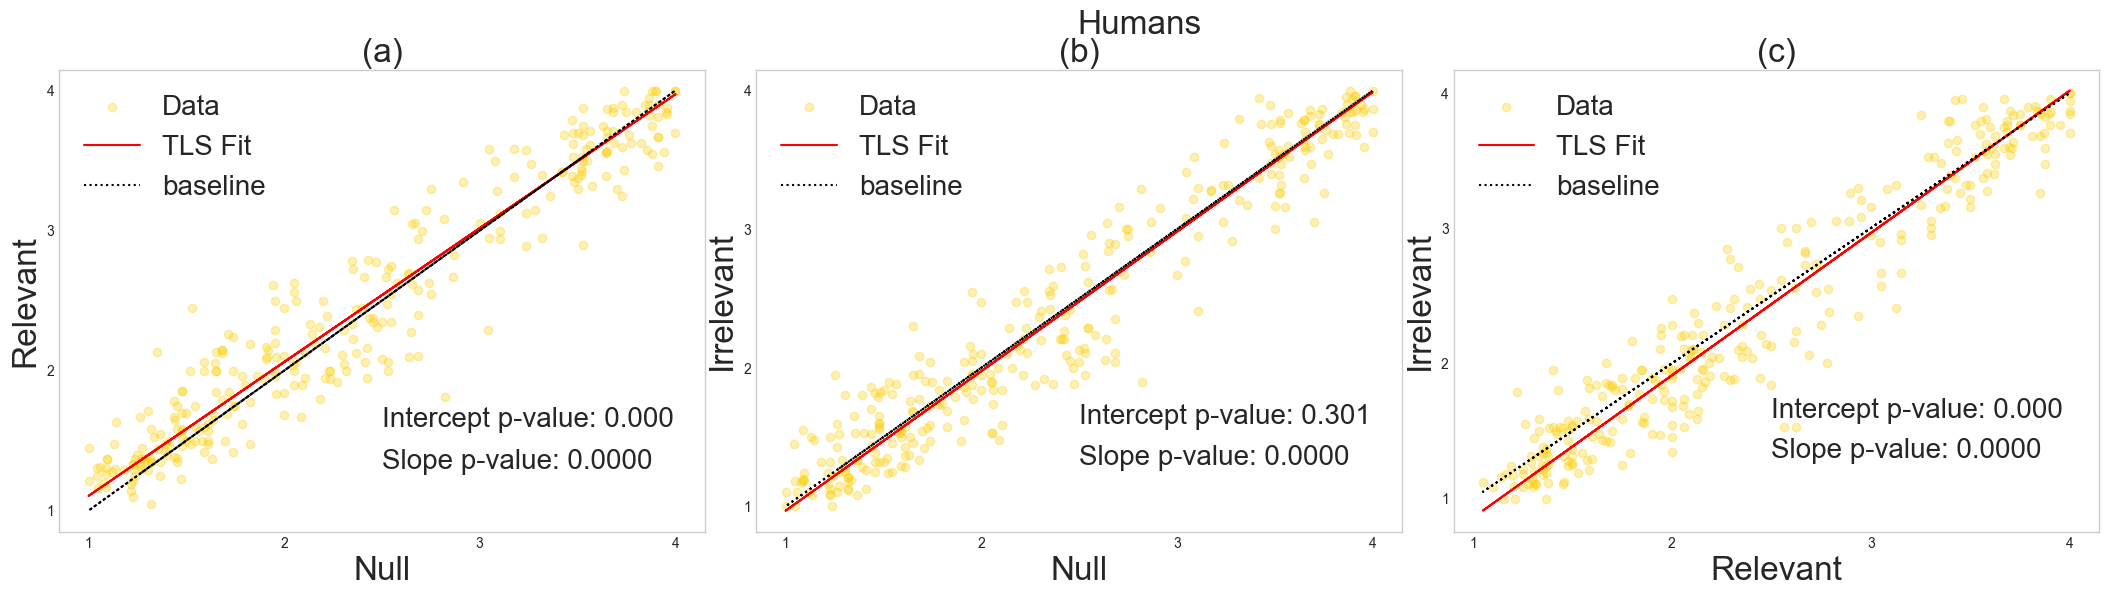

In [2]:
plot_data(scatterplot_data(load_human_data()), rater_who = "Humans", human=True)

#### Regression 2: human ratings by genre

Slope: 0.9714, Intercept: 0.1668
Slope t-val: 47.46, Intercept t-val: 3.53
Slope p-val: 0.0000, Intercept p-val: 0.0006
Slope: 0.9333, Intercept: 0.1940
Slope t-val: 45.07, Intercept t-val: 3.73
Slope p-val: 0.0000, Intercept p-val: 0.0003
Slope: 0.9760, Intercept: 0.0537
Slope t-val: 36.71, Intercept t-val: 0.69
Slope p-val: 0.0000, Intercept p-val: 0.4943


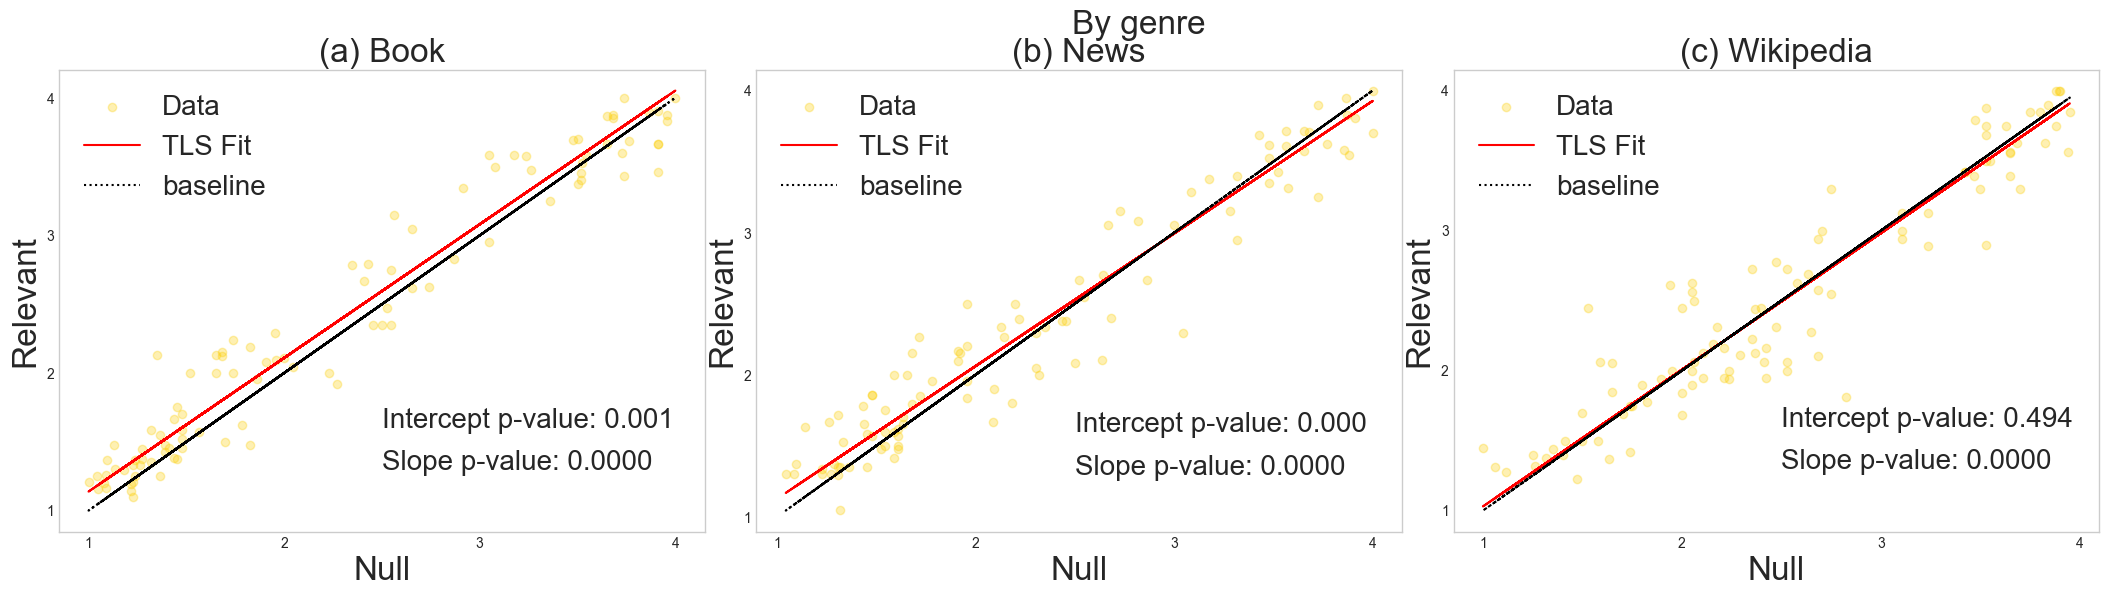

In [3]:
genre = "book"
d1 = scatterplot_data(split_genre(genre))
genre = "news"
d2 = scatterplot_data(split_genre(genre))
genre = "wikipedia"
d3 = scatterplot_data(split_genre(genre))

plot_subdata(d1, d2, d3)

#### Regression 3: model ratings (gpt)

Slope: 0.7977, Intercept: 0.4663
Slope t-val: 68.21, Intercept t-val: 16.30
Slope p-val: 0.0000, Intercept p-val: 0.0000
Slope: 0.8146, Intercept: 0.3887
Slope t-val: 54.91, Intercept t-val: 11.90
Slope p-val: 0.0000, Intercept p-val: 0.0000
Slope: 1.0234, Intercept: -0.0923
Slope t-val: 57.17, Intercept t-val: -2.26
Slope p-val: 0.0000, Intercept p-val: 0.0245
Slope: 0.9260, Intercept: 0.1086
Slope t-val: 79.18, Intercept t-val: 4.30
Slope p-val: 0.0000, Intercept p-val: 0.0000
Slope: 0.9502, Intercept: -0.0178
Slope t-val: 75.20, Intercept t-val: -0.63
Slope p-val: 0.0000, Intercept p-val: 0.5321
Slope: 1.0262, Intercept: -0.1295
Slope t-val: 93.69, Intercept t-val: -4.83
Slope p-val: 0.0000, Intercept p-val: 0.0000


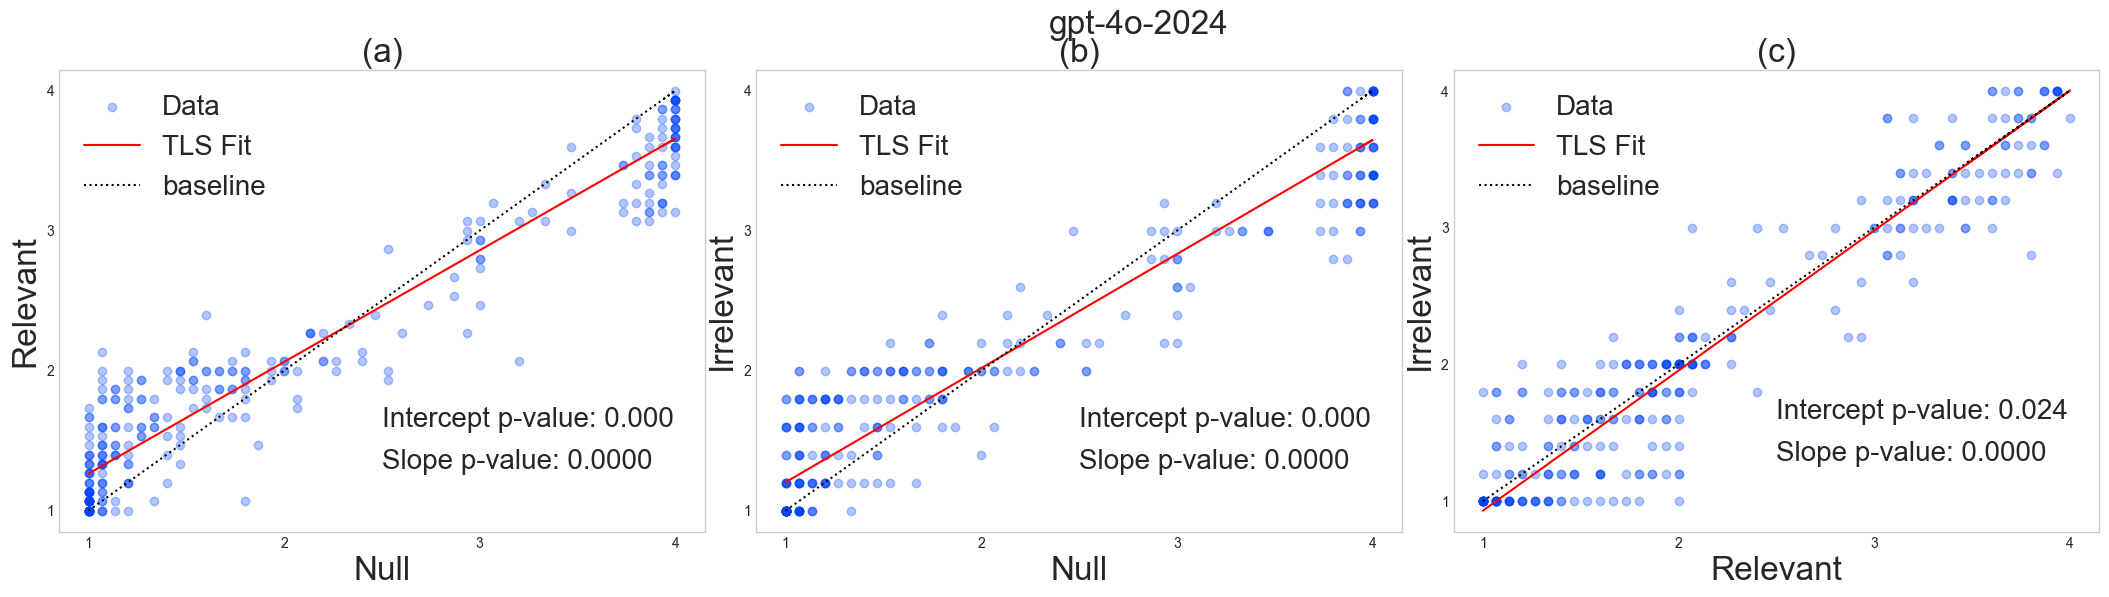

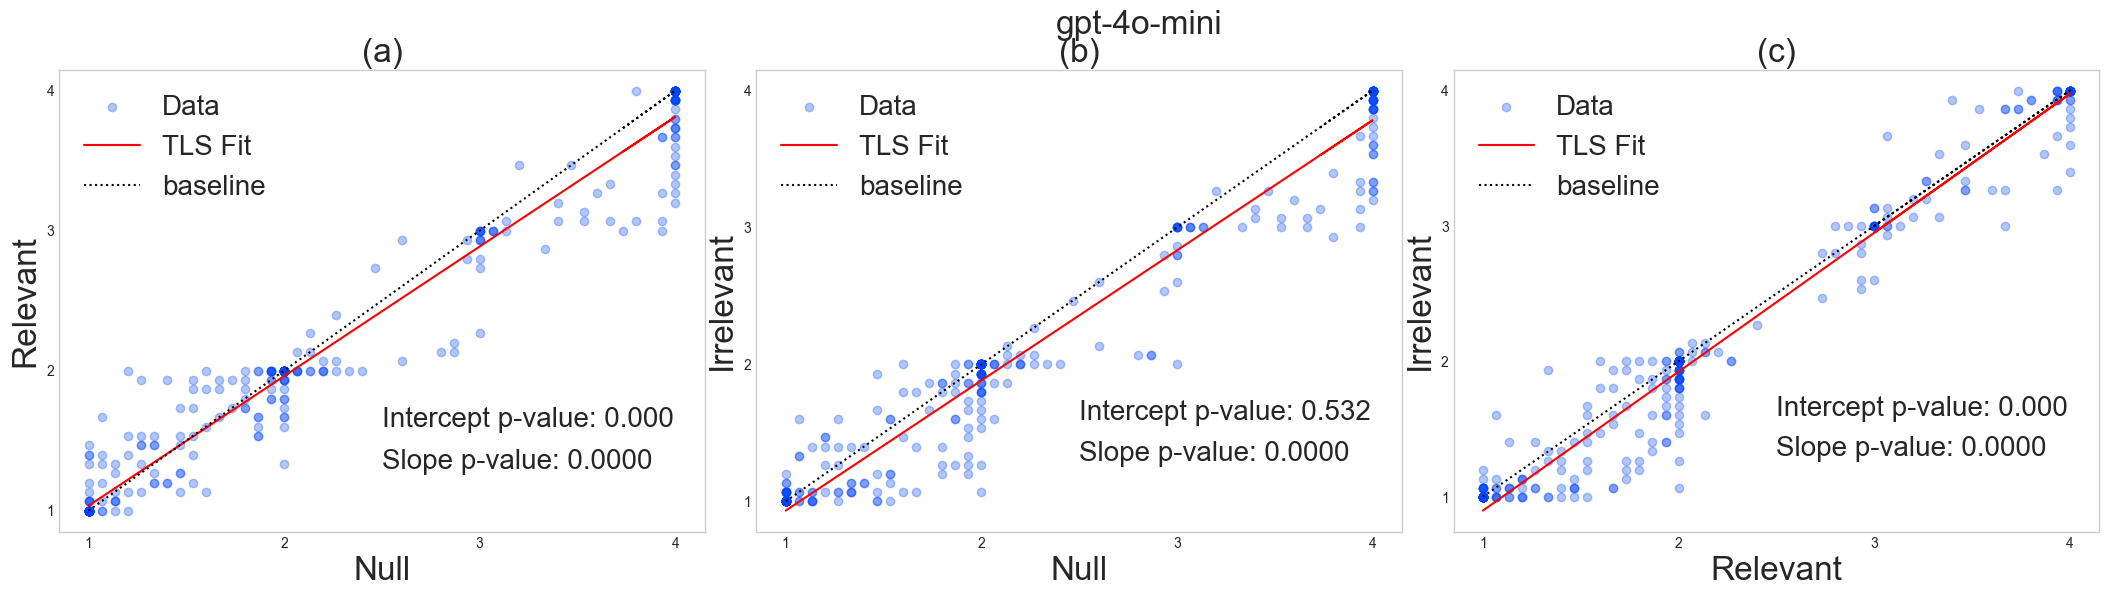

In [4]:
# Closed models
models = ["gpt-4o-2024", "gpt-4o-mini"]

for model in models:
    path = f"./ModelPredictions/*{model}*.csv"
    dat = scatterplot_data(load_model_data(path, open_source=False))
    plot_data(dat, rater_who=model, human=False)

#### Regression 4: model ratings (open-source models)

Slope: 0.5407, Intercept: 0.8920
Slope t-val: 6.47, Intercept t-val: 4.20
Slope p-val: 0.0000, Intercept p-val: 0.0000
Slope: 0.3062, Intercept: 1.2367
Slope t-val: 5.60, Intercept t-val: 8.84
Slope p-val: 0.0000, Intercept p-val: 0.0000
Slope: 0.4924, Intercept: 0.8999
Slope t-val: 4.20, Intercept t-val: 3.39
Slope p-val: 0.0000, Intercept p-val: 0.0008
Slope: 1.6423, Intercept: -1.5507
Slope t-val: 37.21, Intercept t-val: -13.78
Slope p-val: 0.0000, Intercept p-val: 0.0000
Slope: 1.6789, Intercept: -1.8820
Slope t-val: 35.67, Intercept t-val: -15.29
Slope p-val: 0.0000, Intercept p-val: 0.0000
Slope: 1.0258, Intercept: -0.3054
Slope t-val: 52.70, Intercept t-val: -6.19
Slope p-val: 0.0000, Intercept p-val: 0.0000
Slope: 0.9223, Intercept: 0.2350
Slope t-val: 14.56, Intercept t-val: 1.47
Slope p-val: 0.0000, Intercept p-val: 0.1435
Slope: 0.9748, Intercept: -0.1712
Slope t-val: 20.29, Intercept t-val: -1.42
Slope p-val: 0.0000, Intercept p-val: 0.1570
Slope: 1.0510, Intercept: -0.4049

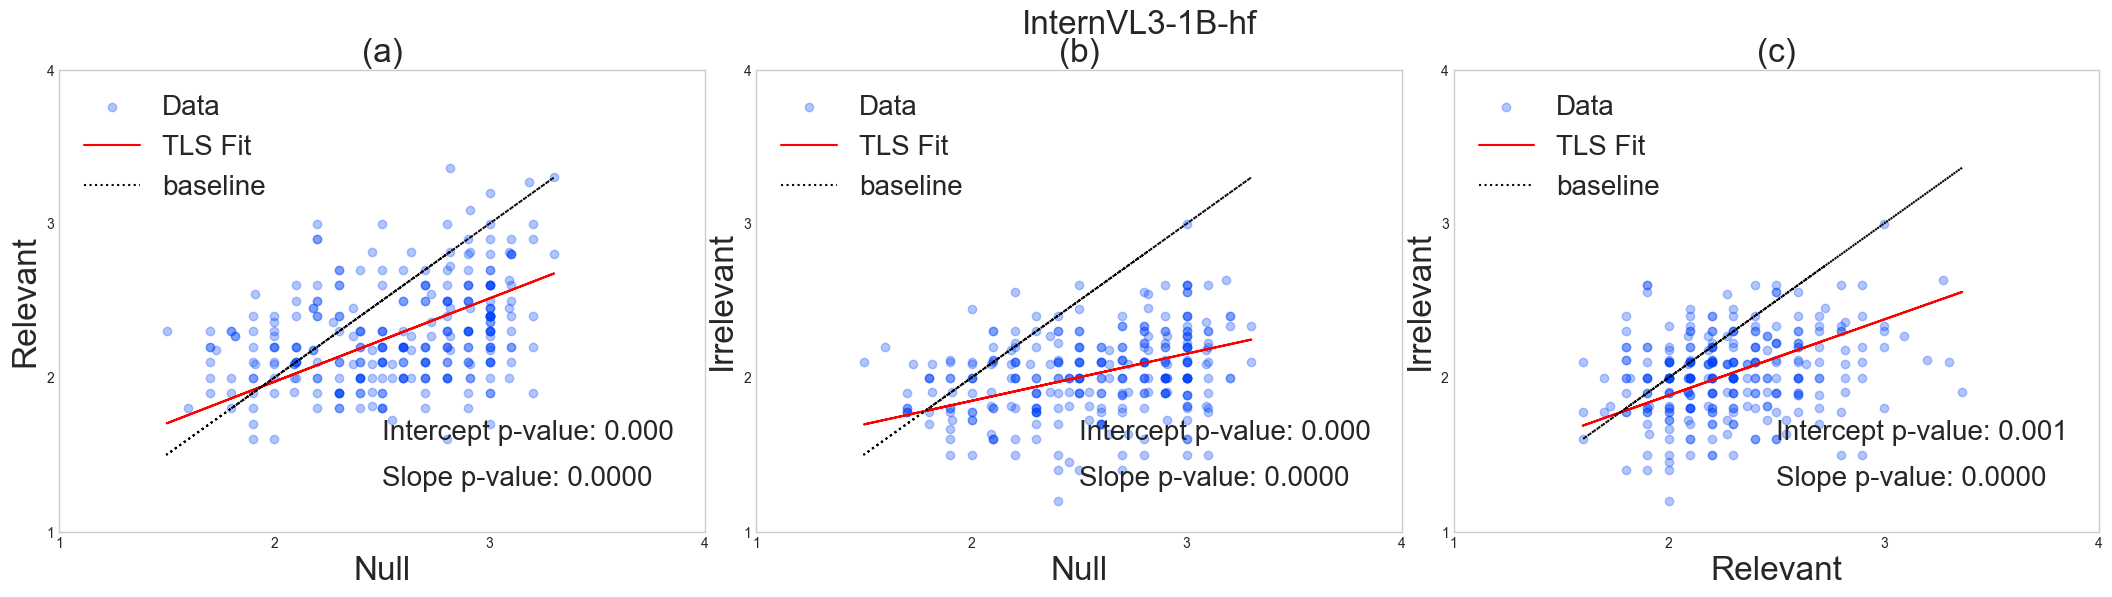

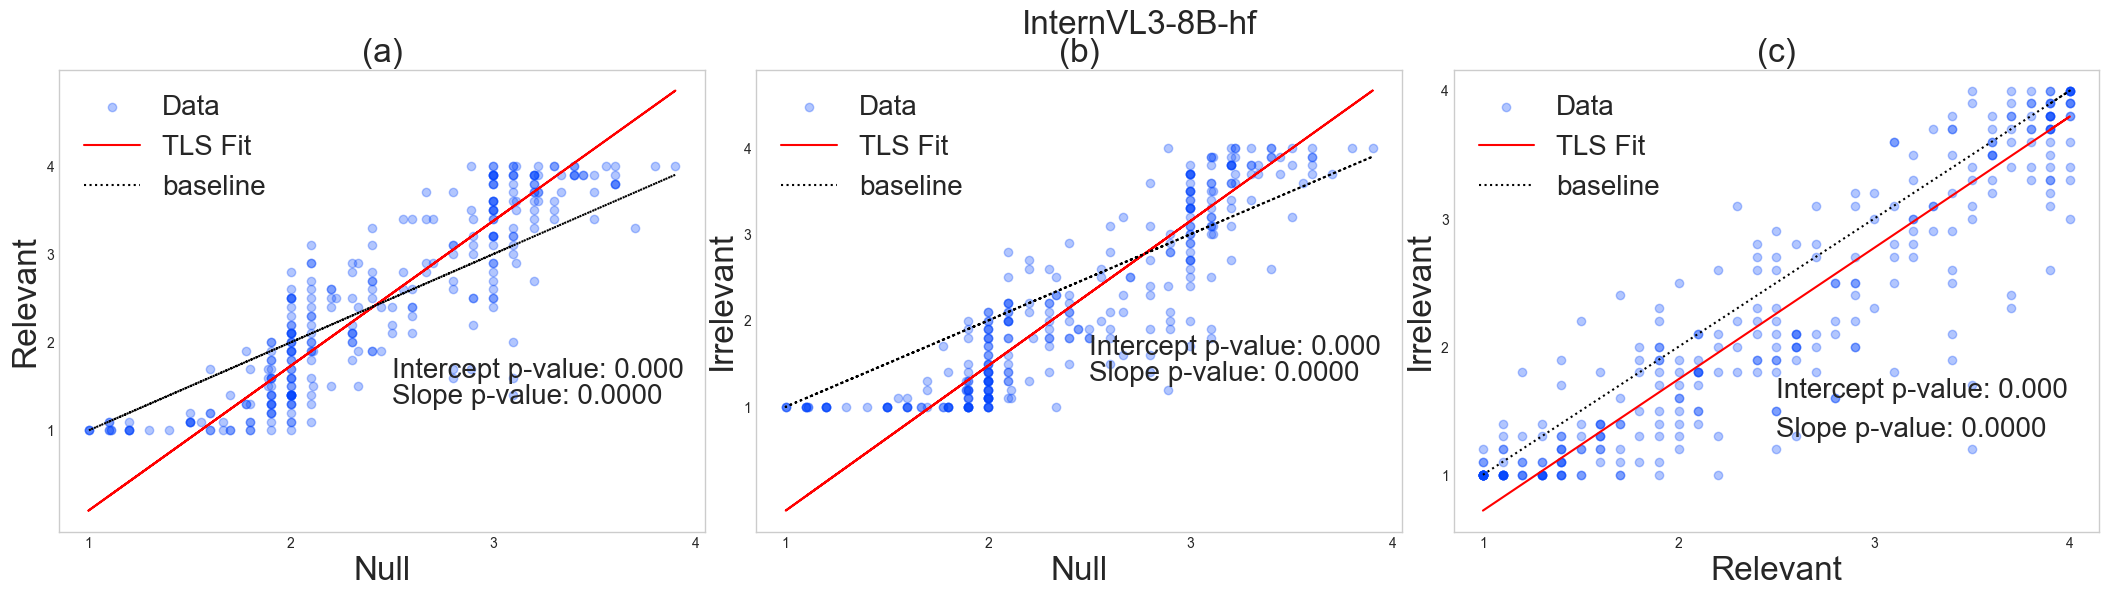

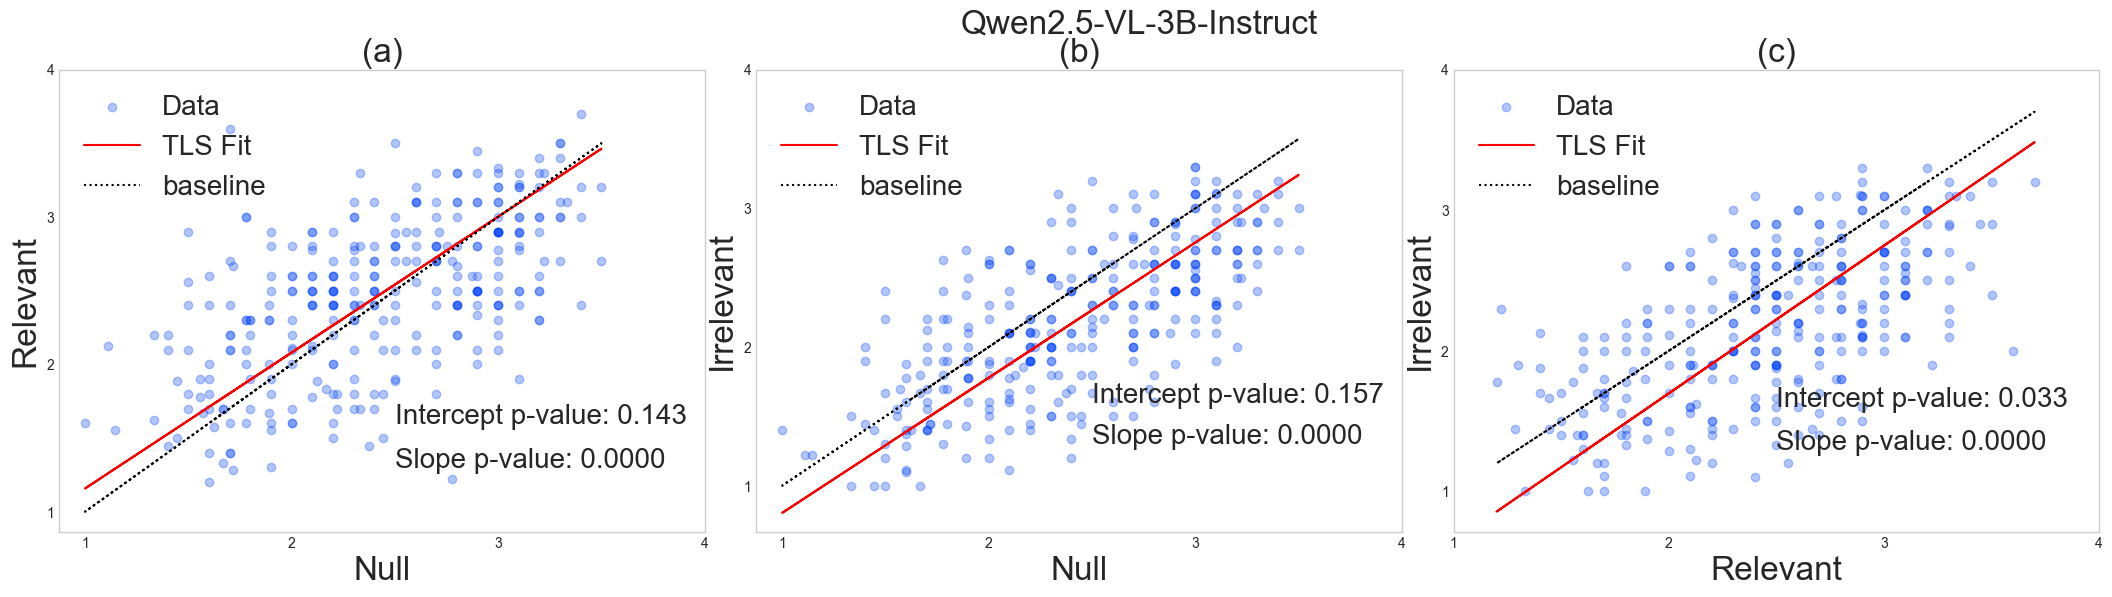

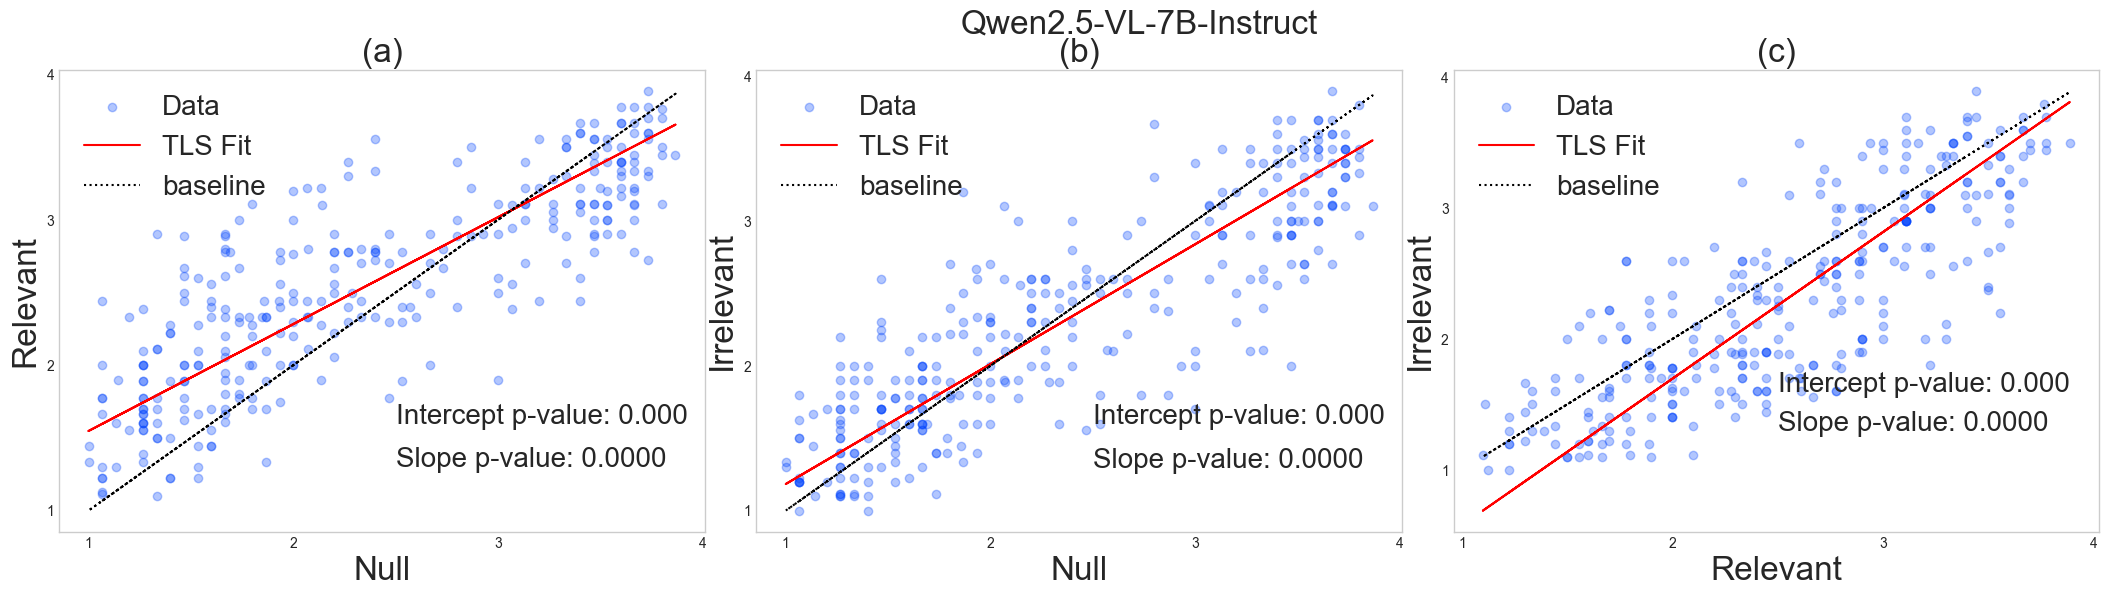

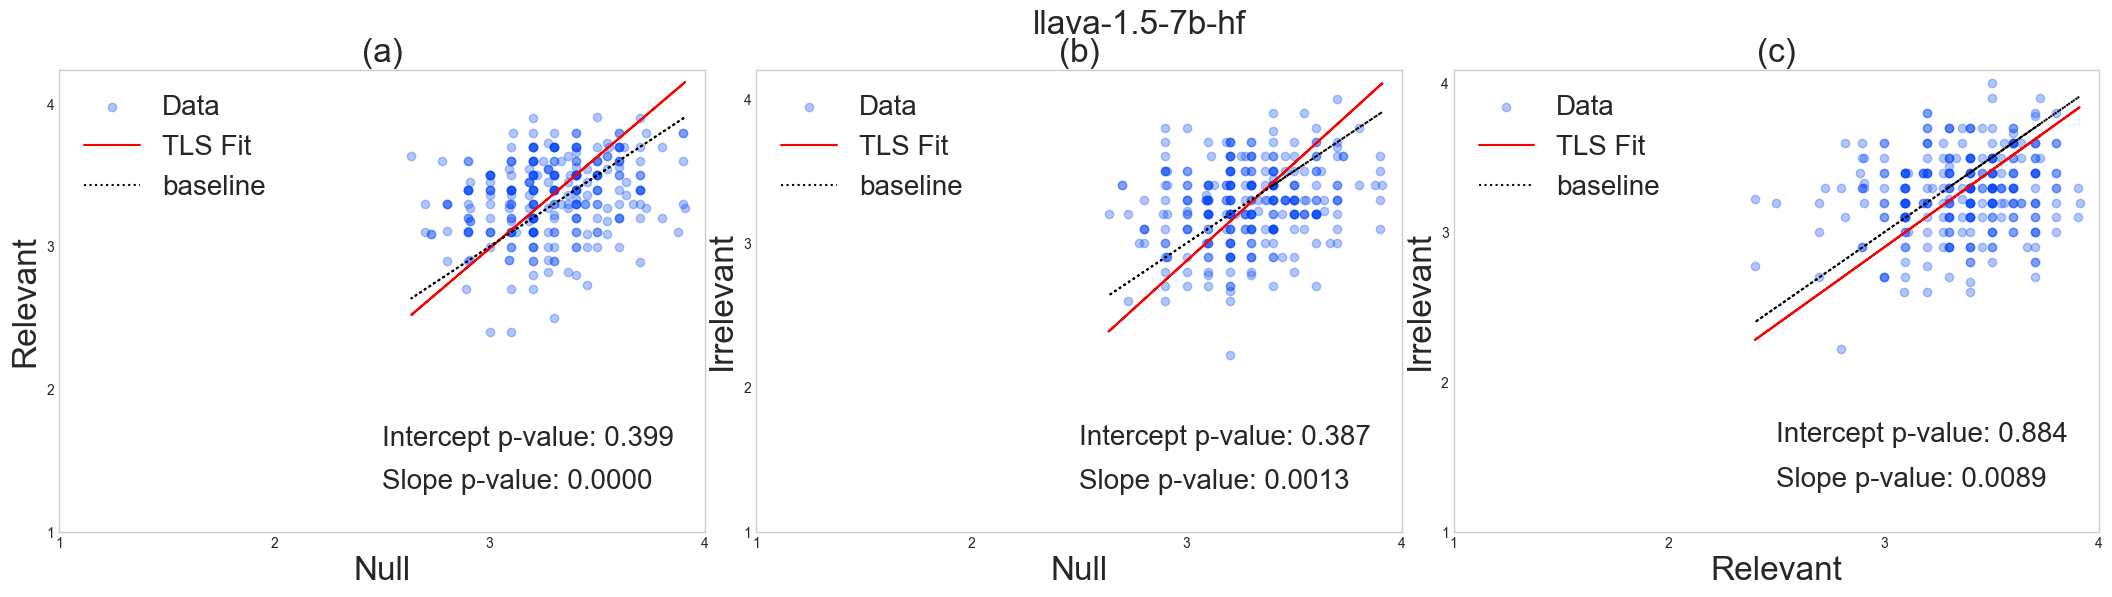

In [5]:
# Open source models
models = ["InternVL3-1B-hf",
          "InternVL3-8B-hf",
          "Qwen2.5-VL-3B-Instruct", 
          "Qwen2.5-VL-7B-Instruct", 
          "llava-1.5-7b-hf"]

for model in models:
    path = f"./ModelPredictions/preds_{model}*.csv"
    dat = scatterplot_data(load_model_data(path, open_source=True))
    plot_data(dat, rater_who=model, human=False)